In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    'CGPA': [5.5, 6.0, 6.2, 6.5, 6.8, 7.0, 7.2, 7.5, 7.8, 8.0,
             8.2, 8.5, 8.7, 9.0, 9.2],

    'Package': [2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 4.3, 4.6, 4.8,
                5.0, 5.5, 5.8, 6.2, 6.5]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,CGPA,Package
0,5.5,2.5
1,6.0,2.8
2,6.2,3.0
3,6.5,3.2
4,6.8,3.5


In [5]:
print("Dataset shape: ", df.shape)

Dataset shape:  (15, 2)


In [6]:
print("Dataset information: ")
df.info()

Dataset information: 
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CGPA     15 non-null     float64
 1   Package  15 non-null     float64
dtypes: float64(2)
memory usage: 372.0 bytes


In [7]:
print("Statistical summary: ")
print(df.describe())
print(df.isnull().sum())

Statistical summary: 
            CGPA    Package
count  15.000000  15.000000
mean    7.473333   4.366667
std     1.139214   1.261330
min     5.500000   2.500000
25%     6.650000   3.350000
50%     7.500000   4.300000
75%     8.350000   5.250000
max     9.200000   6.500000
CGPA       0
Package    0
dtype: int64


In [8]:
X = df[['CGPA']]
y = df[['Package']]

In [9]:
print("Independent Variable (X): CGPA")
print("Dependent Variable (y): Package")

Independent Variable (X): CGPA
Dependent Variable (y): Package


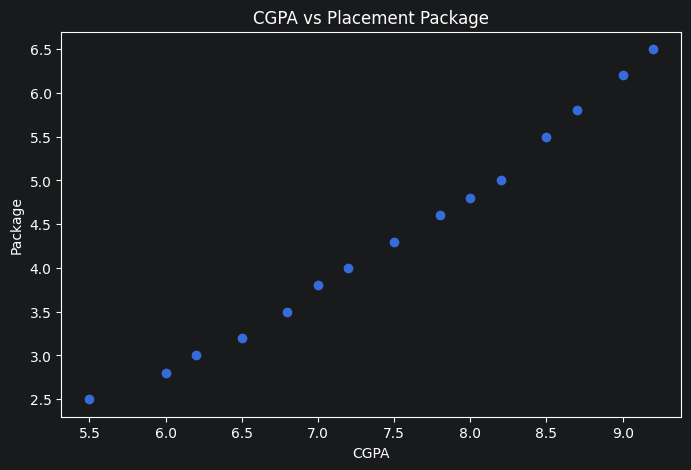

In [10]:
plt.figure(figsize = (8, 5))

plt.scatter(X, y)

plt.xlabel("CGPA")
plt.ylabel("Package")
plt.title("CGPA vs Placement Package")

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Training data: ", X_train)
print("Testing data: ", X_test)

Training data:      CGPA
13   9.0
5    7.0
8    7.8
2    6.2
1    6.0
14   9.2
4    6.8
7    7.5
10   8.2
12   8.7
3    6.5
6    7.2
Testing data:      CGPA
9    8.0
11   8.5
0    5.5


In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

print("Slope (β1): ", model.coef_[0])
print("Intercept (β0): ", model.intercept_)

Slope (β1):  [1.15249758]
Intercept (β0):  [-4.26166935]


In [14]:
y_pred = model.predict(X_test)

print("Actual Values: ", y_test.values)
print("Predicted Values: ", y_pred)

Actual Values:  [[4.8]
 [5.5]
 [2.5]]
Predicted Values:  [[4.95831131]
 [5.5345601 ]
 [2.07706735]]


In [15]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)
print("R² Percentage:", r2 * 100, "%")

R² Score: 0.9583635531071921
R² Percentage: 95.83635531071921 %


In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 0.20526802019551038
Mean Squared Error: 0.06837629834174448


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Package
Feature names seen at fit time, yet now missing:
- CGPA


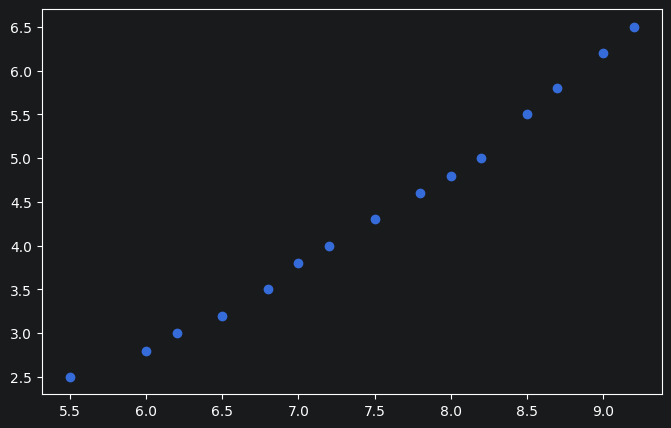

In [17]:
plt.figure(figsize = (8, 5))

plt.scatter(X, y, label = "Actual Data")
plt.plot(X, model.predict(y), label = "Regression Line")

plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("Simple Linear Regression: CGPS vs Placement Package")

plt.legend()
plt.show()

In [18]:
new_cgpa = [[8.5]]
predicted_package = model.predict(new_cgpa)

print("CGPA: ", new_cgpa[0][0])
print("Predicted Placement Package: ", predicted_package[0], "LPA")

CGPA:  8.5
Predicted Placement Package:  [5.5345601] LPA


C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
# Predict for multiple students
new_students = [[7.0], [8.0], [8.5], [9.0], [9.5]]

predicted_packages = model.predict(new_students)

for cgpa, package in zip(new_students, predicted_packages):
    print(f"CGPA: {cgpa[0]} -> Predicted Package: {package.item():.2f} LPA")

CGPA: 7.0 -> Predicted Package: 3.81 LPA
CGPA: 8.0 -> Predicted Package: 4.96 LPA
CGPA: 8.5 -> Predicted Package: 5.53 LPA
CGPA: 9.0 -> Predicted Package: 6.11 LPA
CGPA: 9.5 -> Predicted Package: 6.69 LPA


C:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
